In [1]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs
import cftime

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts

In [2]:
online_cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")["online"]
print(list(online_cat))

['CERES_EBAF', 'ERA5', 'IR_IMERG', 'JRA3Q', 'MERRA2', 'arp-gem-1p3km', 'arp-gem-2p6km', 'casesm2_10km_nocumulus', 'icon_d3hp003', 'icon_d3hp003aug', 'icon_d3hp003feb', 'icon_ngc4008', 'ifs_tco3999-ng5_deepoff', 'ifs_tco3999-ng5_rcbmf', 'ifs_tco3999-ng5_rcbmf_cf', 'ifs_tco3999_rcbmf', 'nicam_220m_test', 'nicam_gl11', 'scream-dkrz', 'tracking-d3hp003', 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest', 'um_glm_n1280_CoMA9_TBv1p2', 'um_glm_n1280_GAL9', 'um_glm_n2560_RAL3p3']


In [3]:
model = online_cat["ERA5"](zoom=6).to_dask()#.pipe(egh.attach_coords)
model

<xarray.Dataset> Size: 136GB
Dimensions:  (time: 1008, cell: 49152, level: 37)
Coordinates:
  * cell     (cell) float32 197kB 0.0 1.0 2.0 ... 4.915e+04 4.915e+04 4.915e+04
    crs      float32 4B ...
    lat      (cell) float32 197kB dask.array<chunksize=(49152,), meta=np.ndarray>
  * level    (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
    lon      (cell) float32 197kB dask.array<chunksize=(49152,), meta=np.ndarray>
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
Data variables: (12/111)
    100u     (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    100v     (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10fg     (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10si     (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10u      (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10v      (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    ...       ...
    uvb      (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    v        (time, level, cell) float32 7GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    vo       (time, level, cell) float32 7GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    w        (time, level, cell) float32 7GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    z        (time, level, cell) float32 7GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    zust     (time, cell) float32 198MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
Attributes:
    acknowledgment:  Contains modified Copernicus Climate Change Service info...
    contact:         lukas.kluft@mpimet.mpg.de
    creator:         Lukas Kluft
    description:     HEALPixelation of ERA5
    source:          Post-processed dataset based on the ERA5 mirror located ...

In [8]:
asym = {}
for model_name in list(online_cat):
    if model_name in ("icon_d3hp003feb", "icon_d3hp003aug", "nicam_220m_test",
            "um_Africa_km4p4_RAL3P3_n1280_GAL9_nest", "um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest",
            "um_SEA_km4p4_RAL3P3_n1280_GAL9_nest", "um_CTC_km4p4_RAL3P3_n1280_GAL9_nest"):
        continue

    try:
        if "ifs" in model_name:
            model = online_cat[model_name](zoom=7).to_dask().pipe(egh.attach_coords)
        # elif "arp" in model_name:
        #     model = online_cat[model_name](zoom=8).to_dask().pipe(egh.attach_coords)
        else:
            model = online_cat[model_name](zoom=4).to_dask().pipe(egh.attach_coords)
        if model_name == "CERES_EBAF":
            rsut = model.toa_sw_all_mon
        elif model_name == "ERA5":
            rsut = model.tsr - model.tsir
            print(rsut)
        elif model_name == "JRA3Q":
            rsut = model.uswrf
        elif model_name == "MERRA2":
            rsut = model.swtdn - model.swtnt
        else:
            rsut = model.rsut

        clim = rsut.groupby("time.month").mean("time").mean("month")
        nh = clim.where(clim.lat > 0).mean("cell")
        sh = clim.where(clim.lat < 0).mean("cell")
        asym[model_name] = {"NH": nh.values, "SH":sh.values, "ASYM":(nh - sh).values}
    except:
        print("some error", model_name)


some error ERA5
some error IR_IMERG
some error JRA3Q
some error arp-gem-1p3km
some error arp-gem-2p6km
some error casesm2_10km_nocumulus
some error ifs_tco3999-ng5_deepoff
some error ifs_tco3999-ng5_rcbmf
some error ifs_tco3999_rcbmf
some error scream-dkrz
some error tracking-d3hp003


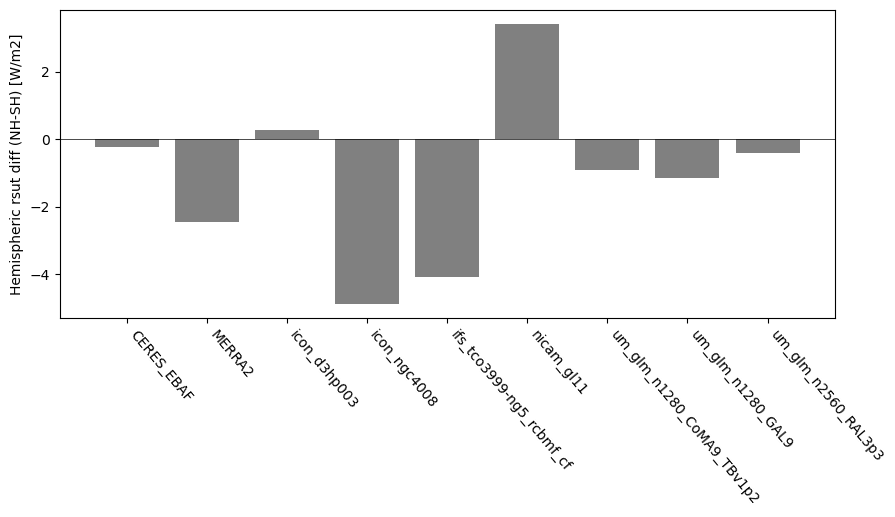

In [14]:
plt.figure(figsize=(10,4))
for k,v in asym.items():
    plt.bar(k, v["ASYM"], color="grey")
plt.axhline(0, lw=0.5, color="k")
plt.ylabel("Hemispheric rsut diff (NH-SH) [W/m2]")
plt.xticks(range(len(asym)), asym.keys(), rotation=-50, ha="left")
plt.savefig("asym_climatology.png", dpi=200, bbox_inches="tight")
plt.show()

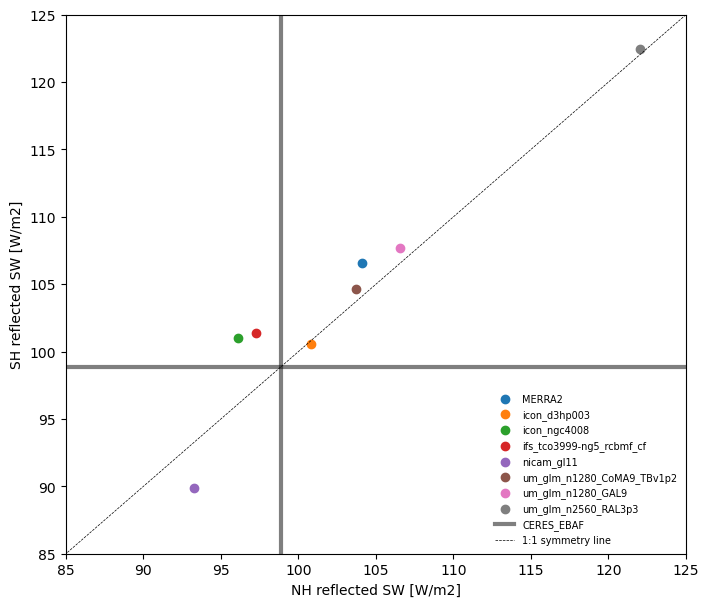

In [37]:
plt.figure(figsize=(8,7))
for k,v in asym.items():
    if k != "CERES_EBAF":
        plt.scatter(v["NH"], v["SH"], marker="o", label=k)
plt.axvline(asym["CERES_EBAF"]["NH"], lw=3, color="k", alpha=0.5, label="CERES_EBAF")
plt.axhline(asym["CERES_EBAF"]["NH"], lw=3, color="k", alpha=0.5)
plt.plot([80,130],[80,130], lw=0.5, ls="--", color="k", label="1:1 symmetry line")
plt.xlim(85,125)
plt.ylim(85,125)
plt.xlabel("NH reflected SW [W/m2]")
plt.ylabel("SH reflected SW [W/m2]")
plt.legend(ncols=1, loc=4, fontsize=7, frameon=False)
plt.savefig("nh_vs_sh_climatology.png", dpi=200, bbox_inches="tight")
plt.show()